In [3]:
%load_ext autoreload
%autoreload 2

import pickle
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.random as jrand

from gvabm.abm_event import sample_event, conditional_sample
from gvabm.abm_ll import city_ll, eval_ds
from gvabm.stat_utils import logrange
from gvabm.city_data import subsampled_city_data, subsample_weights
from gvabm.param_distr import ParamDistr, param_config, mixed_choice_param_config, CityParams, EventOutcome, GeneralParams, MixedGeneralParams


import os
import numpy as np
import scipy.stats as scs
from pyvbmc import VBMC

param_distr = ParamDistr(mixed_choice_param_config)

prior = param_distr.get_uniform_prior()
log_prior = param_distr.get_log_uniform_prior()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:

D = param_distr.param_count
LB = np.full((1, D), -np.inf); UB = np.full((1, D), np.inf)
PLB = param_distr.range_lower.reshape((1, -1)); PUB = param_distr.range_upper.reshape((1, -1))
x0 = np.array([-7.49712599, 38.49844685,  0.70090904, -1.13903331, -4.42167238])
# x0 = np.array(param_distr.sample_range(jrand.PRNGKey(2)))

In [3]:
options = {
    "max_fun_evals": 50 * (D + 2),
    "specify_target_noise": True
    
}
vbmc = VBMC.load(
        "/home/andrew/abm_violence/proc/abm_vbmc_subsampled.pkl",
        new_options=options,
        iteration=None,  # the default: start from the last stored iteration.
        set_random_state=False,  # the default: don't modify the random state
        # (can be set to True for reproducibility).
    )

ModuleNotFoundError: No module named 'param_distr'

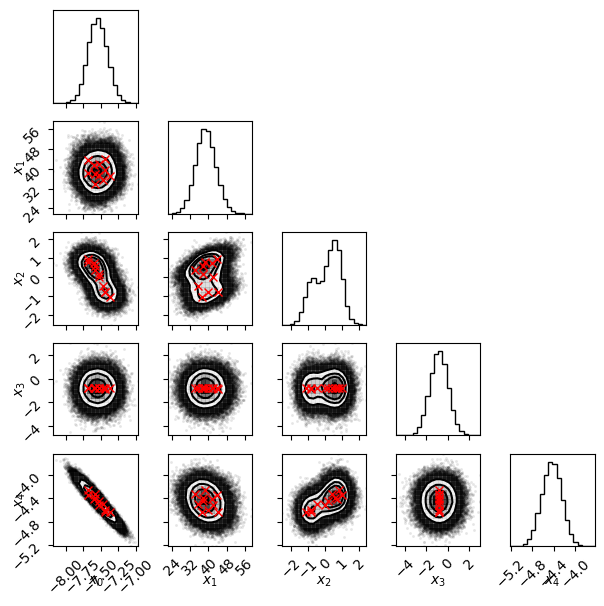

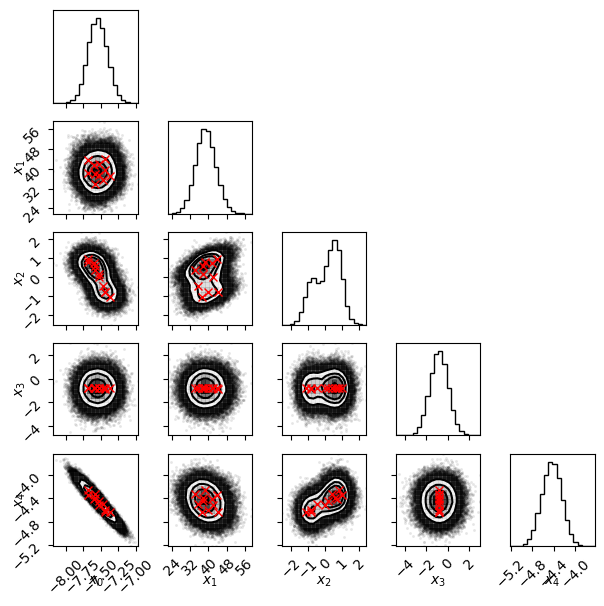

In [15]:
vbmc.vp.plot(plot_vp_centres=True)

In [4]:
print(np.argmax(vbmc.gp.y), vbmc.gp.X[np.argmax(vbmc.gp.y)], vbmc.gp.y[np.argmax(vbmc.gp.y)])
print(np.argmin(vbmc.gp.y), vbmc.gp.X[np.argmin(vbmc.gp.y)], vbmc.gp.y[np.argmin(vbmc.gp.y)])

NameError: name 'vbmc' is not defined

In [6]:
X = vbmc.gp.X
erf = (vbmc.gp.predict(X) - vbmc.gp.y)[0, :]

In [7]:
x_mean = X.mean(axis=0)
print(x_mean)

[ -9.89059996  -2.09684958   2.08711467 -11.21567018 262.67853164]


In [8]:
x_mean = np.array([ 0.04514994,  0,  0.23207941, -0.0,  0.])

In [8]:
samples, ind = vbmc.vp.sample(int(1e6))

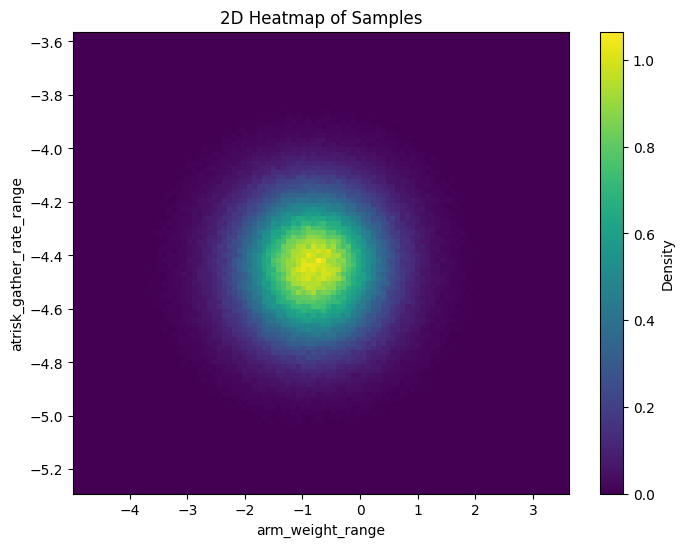

In [11]:
from matplotlib.colors import LogNorm
#Gen 2d heatmap of scatterplot
i, j = 3, 4  # Example indices for the parameters to plot
#hist2d with log scale colormap
plt.figure(figsize=(8, 6))
# plt.hist2d(samples[:, i], samples[:, j], bins=100, density=True, cmap='viridis', norm=LogNorm())
plt.hist2d(samples[:, i], samples[:, j], bins=100, density=True, cmap='viridis') #, norm=LogNorm())
plt.colorbar(label='Density')
plt.xlabel(param_distr.param_names[i])
plt.ylabel(param_distr.param_names[j])
plt.title('2D Heatmap of Samples')
plt.show()

In [39]:
mean_sample = np.mean(samples, axis=0)
print("Param names:", param_distr.param_names)
print(mean_sample)

Param names: ['propensity_range', 'walk_radius_range', 'arm_bias_range', 'arm_weight_range', 'atrisk_gather_rate_range']
[-2.75416106e+00  6.26795527e+03  4.99764670e+00  2.97594420e+00
  2.88996785e+01]
